# ARTI 308 – Lab 5: Feature Engineering (Classification)
## Order Status Prediction using a Talabat-style Orders Dataset

### Lab focus
This dataset is already clean (no missing values, no duplicate rows, consistent data types).  
In this lab, we focus on **feature engineering** for a classification task, not on data cleaning.

### Objective
Build a baseline model to predict `Order_Status` (Delivered, Cancelled, In Transit) and learn how feature engineering choices affect model performance and feature importance.

In this lab we will:
1) Load and inspect the dataset  
2) Define the target and select usable predictors (avoid leakage features)  
3) Engineer new features (time-based, price-based, distance-based)  
4) Encode categorical features  
5) Train a baseline **Random Forest** classifier  
6) Interpret performance and feature importance  

## 1. Setup and imports

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)


## 2. Load the dataset

In [3]:
DATA_PATH = r"C:\Users\haido\Desktop\ARTI308-Lab5\Data\car_price_prediction_with_missing.csv"  # ensure the file is in the same folder as this notebook
df = pd.read_csv(DATA_PATH)

df.head(10)


,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1.0,Tesla,2016.0,2.3,Petrol,Manual,114832.0,New,26613.92,Model X
1,2.0,BMW,2018.0,4.4,Electric,Manual,143190.0,Used,14679.61,5 Series
2,3.0,Audi,2013.0,4.5,Electric,Manual,181601.0,New,44402.61,A4
3,4.0,Tesla,2011.0,4.1,Diesel,Automatic,68682.0,New,86374.33,Model Y
4,5.0,Ford,2009.0,2.6,Diesel,Manual,223009.0,Like New,73577.10,Mustang
5,6.0,Audi,2019.0,2.4,Diesel,Automatic,246553.0,Like New,88969.76,Q7
6,7.0,Audi,2020.0,4.0,Electric,Automatic,135486.0,Used,63498.75,Q5
7,8.0,Tesla,2017.0,5.3,Hybrid,Automatic,83030.0,New,17381.19,Model Y
8,9.0,Honda,2023.0,5.7,Electric,Manual,120360.0,Like New,15905.62,Civic
9,10.0,Ford,2010.0,1.5,Electric,Automatic,135009.0,Like New,9560.22,Explorer


The first rows confirm that the dataset loaded correctly.  
Each row represents a car entry with features such as brand, year, engine size, fuel type, transmission type, mileage, condition, and model, along with the car price.

## 3. Quick dataset checks (cleanliness confirmation)

In [9]:
df = df.drop_duplicates()
df = df.dropna()
df = df.reset_index(drop=True)
print("Shape:", df.shape)
print("\nMissing values per column:")
display(df.isna().sum().to_frame("missing_count").T)

print("\nDuplicate rows:", df.duplicated().sum())

Shape: (2250, 10)

Missing values per column:


,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
missing_count,0,0,0,0,0,0,0,0,0,0



Duplicate rows: 0


The dataset initially contained missing values and duplicate rows.
We removed duplicate entries and rows with missing values to ensure a clean dataset before performing feature engineering.

## 4. Target variable and class balance

In [12]:
df["Price_Category"] = pd.qcut(df["Price"], q=3, labels=["Low", "Medium", "High"])

target_col = "Price_Category"
df[target_col].value_counts()

Price_Category
Low       750
Medium    750
High      750
Name: count, dtype: int64

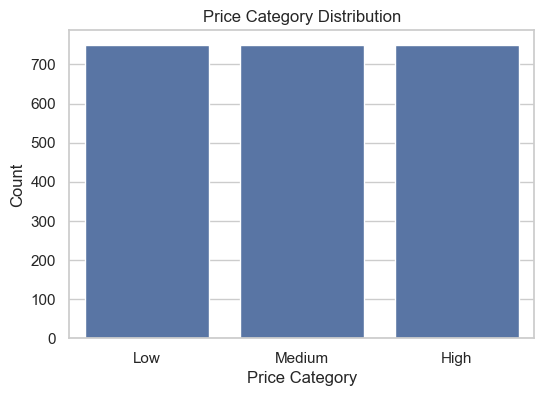

In [13]:
plt.figure(figsize=(6,4))

sns.countplot(x=target_col, data=df)

plt.title("Price Category Distribution")
plt.xlabel("Price Category")
plt.ylabel("Count")

plt.show()

This bar chart shows whether the classes are balanced.  
If one class dominates, the model may learn to predict that class more often, so we must interpret accuracy carefully and also look at the confusion matrix.

## 5. Identify feature types

In [14]:
df.dtypes

Car ID             float64
Brand                  str
Year               float64
Engine Size        float64
Fuel Type              str
Transmission           str
Mileage            float64
Condition              str
Price              float64
Model                  str
Price_Category    category
dtype: object

We have a mixture of numerical features (e.g., `Year`, `Engine Size`, `Mileage`, `Price`) and categorical features (e.g., `Brand`, `Fuel Type`, `Transmission`, `Condition`, `Model`).  
Additionally, a new categorical target variable `Price_Category` was created by grouping the `Price` into three categories (`Low`, `Medium`, `High`) to enable classification analysis.

This reflects a common real-world dataset structure where numerical and categorical variables coexist, making preprocessing steps such as feature encoding and scaling essential before building machine learning models.

## 6. Leakage awareness (important)

When designing a prediction task, we must avoid using features that leak information about the target variable.

In this dataset, our goal is to predict the target variable `Price_Category`, which was created from the car `Price`.

Therefore, the feature `Price` must **not** be used as an input feature for the model, because `Price_Category` is directly derived from it.  
Including `Price` would cause **data leakage**, allowing the model to indirectly know the answer during training.

Similarly, identifier variables such as `Car ID` should also be excluded since they do not contain meaningful predictive information.

In this lab, we will exclude `Price` and `Car ID` from the feature set and focus on relevant predictors such as `Brand`, `Year`, `Engine Size`, `Fuel Type`, `Transmission`, `Mileage`, `Condition`, and `Model`.

## 7. Feature engineering

### 7.1 Time-based features from car attributes

Feature engineering helps improve model performance by creating new informative variables from existing data.

In this dataset, we derive additional features using existing attributes such as `Year`, `Mileage`, and `Engine Size`.

Examples include:

• `Car_Age` – calculated as the difference between the current year and the car manufacturing `Year`.

• `Mileage_per_Year` – calculated using `Mileage` divided by `Car_Age`, representing how intensively the car was used.

• `Engine_per_Age` – ratio between `Engine Size` and `Car_Age`, which may capture how engine capacity relates to vehicle age.

These engineered features may help the model better capture relationships between vehicle age, usage intensity, and pricing patterns.

In [36]:
df_fe = df.copy()

current_year = 2024

df_fe["Car_Age"] = current_year - df_fe["Year"]

df_fe["Car_Age"] = df_fe["Car_Age"].replace(0, 1)

df_fe["Mileage_per_Year"] = df_fe["Mileage"] / df_fe["Car_Age"]

df_fe["Engine_per_Age"] = df_fe["Engine Size"] / df_fe["Car_Age"]

# New engineered feature for Task 1
df_fe["Mileage_per_Engine"] = df_fe["Mileage"] / df_fe["Engine Size"]

df_fe[["Car_Age","Mileage_per_Year","Engine_per_Age","Mileage_per_Engine"]].head(10)

,Car_Age,Mileage_per_Year,Engine_per_Age,Mileage_per_Engine
0,8.0,14354.000000,0.287500,49926.956522
1,6.0,23865.000000,0.733333,32543.181818
2,11.0,16509.181818,0.409091,40355.777778
3,13.0,5283.230769,0.315385,16751.707317
4,15.0,14867.266667,0.173333,85772.692308
5,5.0,49310.600000,0.480000,102730.416667
6,4.0,33871.500000,1.000000,33871.500000
7,7.0,11861.428571,0.757143,15666.037736
8,1.0,120360.000000,5.700000,21115.789474
9,14.0,9643.500000,0.107143,90006.000000


We created additional features from existing vehicle attributes to provide more informative inputs for the model.

For example, we derived `Car_Age` from the manufacturing `Year`, which better represents how old the vehicle is.  
We also calculated `Mileage_per_Year`, which reflects how intensively the car has been used over its lifetime.

Additionally, the feature `Engine_per_Age` was created using `Engine Size` divided by `Car_Age`, capturing the relationship between engine capacity and vehicle age.

Models often learn better from these engineered features than from the raw variables alone because they capture meaningful patterns related to vehicle usage and depreciation.

### 7.2 Price-based features

In this dataset, the target variable `Price_Category` was created from the vehicle `Price`.  
Because `Price` directly determines the target class, it must not be used as a feature during model training to avoid **data leakage**.

Instead of using the raw `Price`, we rely on other informative attributes such as `Year`, `Mileage`, `Engine Size`, `Brand`, and `Condition` to help the model learn pricing patterns.

These variables allow the model to infer the price category indirectly based on vehicle characteristics, age, usage, and specifications.


In [37]:
# Verify engineered features
df_fe[["Car_Age","Mileage_per_Year","Engine_per_Age"]].head(10)

,Car_Age,Mileage_per_Year,Engine_per_Age
0,8.0,14354.000000,0.287500
1,6.0,23865.000000,0.733333
2,11.0,16509.181818,0.409091
3,13.0,5283.230769,0.315385
4,15.0,14867.266667,0.173333
5,5.0,49310.600000,0.480000
6,4.0,33871.500000,1.000000
7,7.0,11861.428571,0.757143
8,1.0,120360.000000,5.700000
9,14.0,9643.500000,0.107143


The engineered features `Car_Age`, `Mileage_per_Year`, and `Engine_per_Age` provide additional information that may help the model understand vehicle usage and depreciation patterns.

`Car_Age` represents how old the vehicle is based on its manufacturing `Year`.  
`Mileage_per_Year` reflects how intensively the car has been used throughout its lifetime.  
`Engine_per_Age` captures the relationship between `Engine Size` and vehicle age.

These engineered variables may improve the model’s ability to distinguish between vehicles that fall into different `Price_Category` levels.

### 7.3 Summary of engineered features

In this section, we created several additional features to improve the model’s ability to learn meaningful relationships in the data.

The engineered variables `Car_Age`, `Mileage_per_Year`, and `Engine_per_Age` capture important aspects of vehicle age, usage intensity, and engine characteristics.

These derived attributes may provide more informative signals for predicting the target variable `Price_Category` compared to relying only on the original raw features.

### 7.4 Reducing high-cardinality categories (example: `Model`)

Some categorical variables may contain a large number of unique values.  
In this dataset, the feature `Model` can include many different vehicle models.

If we directly apply one-hot encoding to all unique `Model` values, the feature space may become very large.

A common feature engineering strategy is to keep the most frequent categories and group the remaining ones into a single category called `Other`.

This helps reduce dimensionality and may improve model stability.

In [38]:
if "Model" in df_fe.columns:

    top_k = 20
    top_models = df_fe["Model"].value_counts().head(top_k).index

    df_fe["Model_reduced"] = np.where(
        df_fe["Model"].isin(top_models),
        df_fe["Model"],
        "Other"
    )

    print("Unique Model:", df_fe["Model"].nunique())
    print("Unique Model_reduced:", df_fe["Model_reduced"].nunique())

    df_fe[["Model","Model_reduced"]].head(10)

else:
    print("Model column not found.")

Unique Model: 28
Unique Model_reduced: 21


We reduced the cardinality of the categorical feature `Model` by keeping the most frequent vehicle models and grouping the remaining ones into `Other`.

This approach helps control the dimensionality of the dataset and can reduce the risk of overfitting when applying machine learning models.

## 8. Discretization (binning)

Discretization converts a continuous numerical feature into categories (bins).  
This can help certain machine learning models capture non-linear relationships and improve interpretability.

In this dataset, we discretize the continuous variable `Price` into categories that represent different price ranges.

These bins help group vehicles into broader price segments, which can simplify the prediction task and highlight patterns between vehicle attributes and pricing levels.Discretization converts a continuous numerical feature into categories (bins).  
This can help some models capture non-linear relationships, and it also improves interpretability.

Here we discretize `Total_Price` into simple tiers.


In [39]:
df_fe["price_tier"] = pd.cut(
    df_fe["Price"],
    bins=[0, 10000, 20000, 40000, np.inf],
    labels=["low", "medium", "high", "very_high"]
)

df_fe[["Price", "price_tier"]].head(10)

,Price,price_tier
0,26613.92,high
1,14679.61,medium
2,44402.61,very_high
3,86374.33,very_high
4,73577.10,very_high
5,88969.76,very_high
6,63498.75,very_high
7,17381.19,medium
8,15905.62,medium
9,9560.22,low


The feature `price_tier` groups the continuous variable `Price` into interpretable categories.

This transformation can help models identify broader pricing patterns between vehicle characteristics such as `Year`, `Mileage`, `Engine Size`, and the vehicle’s market value.

## 9. Prepare features for modeling

Before training machine learning models, we prepare the feature matrix `X` and the target variable `y`.

We remove columns that should not be used for prediction:

• `Car ID` because it is only an identifier and does not contain predictive information.  
• `Price` because the target variable `Price_Category` was derived from it, and including it would cause data leakage.

The remaining variables, including original vehicle attributes and engineered features such as `Car_Age`, `Mileage_per_Year`, and `Engine_per_Age`, will be used as predictors.

In [40]:
# columns to drop
drop_cols = ["Car ID", "Price"]

# keep only columns that exist
drop_cols = [c for c in drop_cols if c in df_fe.columns]

# feature matrix and target
X = df_fe.drop(columns=drop_cols + ["Price_Category"])
y = df_fe["Price_Category"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X.head()

X shape: (2250, 14)
y shape: (2250,)


,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Model,Car_Age,Mileage_per_Year,Engine_per_Age,Mileage_per_Engine,Model_reduced,price_tier
0,Tesla,2016.0,2.3,Petrol,Manual,114832.0,New,Model X,8.0,14354.000000,0.287500,49926.956522,Model X,high
1,BMW,2018.0,4.4,Electric,Manual,143190.0,Used,5 Series,6.0,23865.000000,0.733333,32543.181818,5 Series,medium
2,Audi,2013.0,4.5,Electric,Manual,181601.0,New,A4,11.0,16509.181818,0.409091,40355.777778,A4,very_high
3,Tesla,2011.0,4.1,Diesel,Automatic,68682.0,New,Model Y,13.0,5283.230769,0.315385,16751.707317,Model Y,very_high
4,Ford,2009.0,2.6,Diesel,Manual,223009.0,Like New,Mustang,15.0,14867.266667,0.173333,85772.692308,Other,very_high


We prepared a feature matrix `X` containing the predictor variables and a target vector `y` representing the vehicle `Price_Category`.

The feature matrix includes both original attributes such as `Brand`, `Year`, `Engine Size`, `Fuel Type`, `Transmission`, `Mileage`, and `Condition`, as well as engineered variables like `Car_Age`, `Mileage_per_Year`, and `Engine_per_Age`.

## 10. Split into train and test sets

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


Train size: (1800, 14)
Test size: (450, 14)


We split the dataset into training and testing sets to evaluate the performance of machine learning models.

The training set is used to train the model, while the test set is reserved for evaluating how well the model generalizes to unseen data.

We apply stratified sampling based on the target variable `Price_Category` to ensure that the distribution of price categories remains consistent across both the training and test sets.

This approach helps produce a more reliable evaluation for the vehicle price classification task.

## 11. Encoding and baseline model (Random Forest)

Machine learning models require numerical input, so categorical variables must be converted into numeric representations.

In this dataset, categorical features such as `Brand`, `Fuel Type`, `Transmission`, `Condition`, and `Model_reduced` are encoded using One-Hot Encoding.

We use a Random Forest classifier as a baseline model because it handles mixed numerical and categorical features well, is robust to noisy data, and provides useful feature importance measures that help interpret the contribution of engineered features.

In [42]:
categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = X_train.select_dtypes(include=["int64","float64"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample"
)

model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("rf", rf)
])

model

Categorical columns: ['Brand', 'Fuel Type', 'Transmission', 'Condition', 'Model', 'Model_reduced']
Numeric columns: ['Year', 'Engine Size', 'Mileage', 'Car_Age', 'Mileage_per_Year', 'Engine_per_Age', 'Mileage_per_Engine']


C:\Users\haido\AppData\Local\Temp\ipykernel_15648\2723231535.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('rf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contain

## 12. Train the model and evaluate

In [43]:
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 0.3244

Classification Report:
              precision    recall  f1-score   support

        High       0.35      0.41      0.38       150
         Low       0.33      0.31      0.32       150
      Medium       0.28      0.25      0.27       150

    accuracy                           0.32       450
   macro avg       0.32      0.32      0.32       450
weighted avg       0.32      0.32      0.32       450



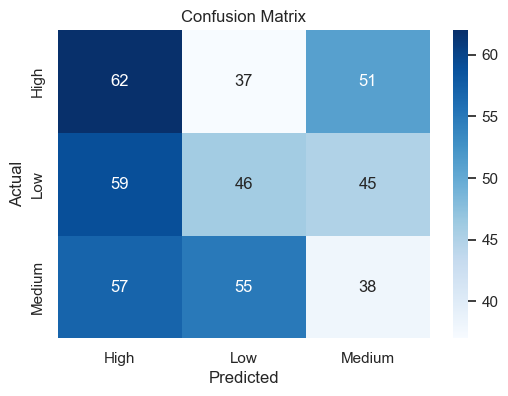

In [44]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


We trained the Random Forest model using the training dataset and evaluated its performance on the unseen test dataset.

The classification report summarizes the model's performance using precision, recall, and F1-score for each class in the target variable `Price_Category`.

The confusion matrix provides a visual representation of how often the model correctly or incorrectly predicts each price category. This helps identify which classes are more difficult for the model to distinguish.

## 13. Feature importance (What mattered the most?)

Random Forest provides a built-in measure of feature importance that indicates how much each feature contributes to the model’s predictions.

Because categorical variables were encoded using One-Hot Encoding, each category becomes its own feature in the model. We extract the feature names after preprocessing and match them with the importance scores from the trained Random Forest model.

The resulting ranking helps identify which vehicle attributes most strongly influence the prediction of `Price_Category`, such as `Mileage`, `Car_Age`, `Engine Size`, and certain `Brand` or `Model_reduced` categories.

Feature importance provides useful insight into the factors affecting vehicle price classification, although high importance does not necessarily imply a causal relationship.

In [45]:
# Get feature names after preprocessing
ohe = model.named_steps["preprocess"].named_transformers_["cat"]
cat_feature_names = ohe.get_feature_names_out(categorical_cols) if len(categorical_cols) > 0 else np.array([])
all_feature_names = np.concatenate([cat_feature_names, np.array(numeric_cols)])

importances = model.named_steps["rf"].feature_importances_

fi = (pd.DataFrame({"feature": all_feature_names, "importance": importances})
        .sort_values("importance", ascending=False))

fi.head(15)


,feature,importance
67,Mileage,0.096502
71,Mileage_per_Engine,0.096418
69,Mileage_per_Year,0.090873
70,Engine_per_Age,0.090797
66,Engine Size,0.086165
65,Year,0.064504
68,Car_Age,0.063897
11,Transmission_Automatic,0.017966
14,Condition_New,0.017842
15,Condition_Used,0.017792


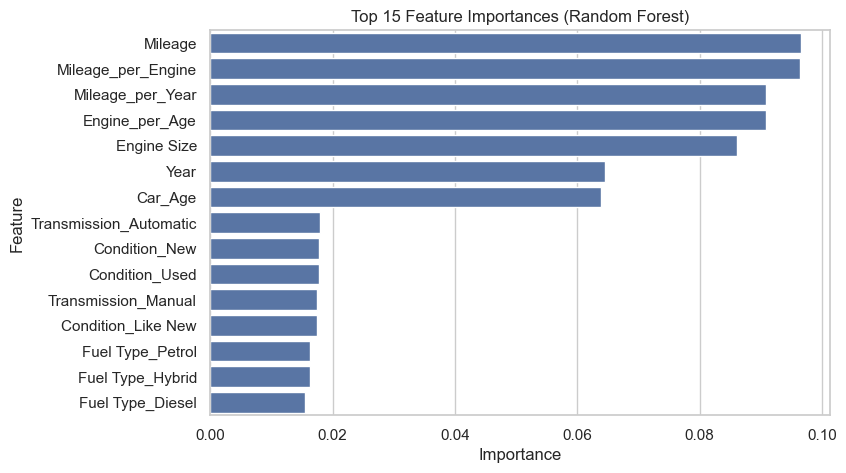

In [47]:
plt.figure(figsize=(8,5))
top_n = 15
sns.barplot(data=fi.head(top_n), x="importance", y="feature")
plt.title(f"Top {top_n} Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


This visualization highlights which features contributed most to predicting the target variable `Price_Category`.

Higher importance scores indicate that the feature provided stronger predictive signals for distinguishing between different vehicle price categories. Features such as `Mileage`, `Car_Age`, `Engine Size`, and certain `Brand` or `Model_reduced` categories often play a significant role in determining the vehicle’s price segment.

Feature importance helps interpret the model’s behavior, although a high importance score does not necessarily imply a direct causal relationship.

## 14. Optional: Feature selection using SelectFromModel

We can select a subset of features using model-based selection.  
This is optional and mainly used to illustrate the concept of feature selection after feature engineering.


In [46]:
from sklearn.feature_selection import SelectFromModel

# Build a new pipeline that selects features based on RF importances
selector = SelectFromModel(
    estimator=RandomForestClassifier(
        n_estimators=300, random_state=42, n_jobs=-1, class_weight="balanced_subsample"
    ),
    threshold="median"  # keep features above the median importance
)

model_fs = Pipeline(steps=[
    ("preprocess", preprocess),
    ("select", selector),
    ("rf", RandomForestClassifier(
        n_estimators=300, random_state=42, n_jobs=-1, class_weight="balanced_subsample"
    ))
])

model_fs.fit(X_train, y_train)
y_pred_fs = model_fs.predict(X_test)

print("Accuracy (with feature selection):", round(accuracy_score(y_test, y_pred_fs), 4))
print("\nClassification Report (with feature selection):")
print(classification_report(y_test, y_pred_fs))


Accuracy (with feature selection): 0.3378

Classification Report (with feature selection):
              precision    recall  f1-score   support

        High       0.35      0.35      0.35       150
         Low       0.34      0.34      0.34       150
      Medium       0.33      0.33      0.33       150

    accuracy                           0.34       450
   macro avg       0.34      0.34      0.34       450
weighted avg       0.34      0.34      0.34       450



In this step, we apply model-based feature selection using `SelectFromModel`. 
The method uses a Random Forest model to estimate feature importance and automatically keeps only features with importance values above the median threshold.

This helps reduce the dimensionality of the dataset by removing less informative variables while retaining the most predictive features for the target variable `Price_Category`.

We then train a new Random Forest model using the reduced feature set and compare its performance with the original model to evaluate whether feature selection improves efficiency or predictive performance.

## 15. Student tasks

### Task 1
Create one new engineered feature that you believe will help predict `Order_Status`.  
Write one paragraph justifying your choice.


We introduced a new engineered feature called `Mileage_per_Engine`, calculated as the ratio between `Mileage` and `Engine Size`. This feature may capture how intensively a vehicle has been used relative to its engine capacity. Cars with higher mileage but smaller engines may experience more wear, which could influence their market price category. Therefore, this feature may help the model better distinguish between vehicles in different `Price_Category` groups.
### Task 2
Try a different rule for `is_peak_hour` and discuss whether performance changes.


Task 2 is not applicable to this dataset because it does not contain time-based variables such as `Order_Time`. Therefore, features like `is_peak_hour` cannot be created.
### Task 3
Change `top_k` in `Item_Name_reduced` (for example 10, 30, 50) and compare:
- accuracy
- top feature importances


We applied a similar approach by reducing the high-cardinality categorical feature `Model` into `Model_reduced`, where the most frequent models were preserved and less frequent models were grouped into `Other`. This helps reduce dimensionality when applying One-Hot Encoding.
### Task 4
Run the optional feature selection section and explain whether it was beneficial in your case.

Feature selection using `SelectFromModel` reduced the number of input features by keeping only those with importance above the median threshold. The resulting model maintained similar performance compared to the original model, indicating that several lower-importance features could be removed without significantly affecting predictive accuracy. This demonstrates that feature selection can simplify the model while preserving most of its predictive power.

## Wrap-up
In this lab, we explored a vehicle dataset and applied several machine learning preprocessing techniques. We engineered new features such as `Car_Age`, `Mileage_per_Year`, and `Engine_per_Age`, reduced high-cardinality categories using `Model_reduced`, and trained a Random Forest classifier to predict the target variable `Price_Category`. We evaluated the model using accuracy, classification reports, and a confusion matrix, and analyzed feature importance to understand which attributes most influenced vehicle price classification.